# Week 2 · Lecture 2 — Evidence Approximation and Automatic Relevance Determination

## Learning objectives

1. Define the **marginal likelihood** (evidence) for Bayesian linear regression and compute it in closed form.
2. Derive the **evidence approximation** (a.k.a. type-II maximum likelihood, empirical Bayes) update equations for $\alpha$ and $\beta$.
3. Implement the iterative fixed-point procedure and recover the optimal regularisation strength from data alone.
4. Generalise to **Automatic Relevance Determination (ARD)**, where each basis function gets its own precision $\alpha_j$, and watch irrelevant basis functions get pruned to near-zero weight.

## 1. The marginal likelihood

The marginal likelihood is the normalising constant of the posterior:

$$
p(\mathbf{y} \mid \alpha, \beta) \;=\; \int p(\mathbf{y} \mid w, \beta)\, p(w \mid \alpha)\, dw.
$$

For our Gaussian-Gaussian model both factors are Gaussian, so this Gaussian integral admits a closed form. The log evidence (a.k.a. *log marginal likelihood*) is

$$
\log p(\mathbf{y} \mid \alpha, \beta) \;=\; \tfrac{M}{2}\log\alpha + \tfrac{N}{2}\log\beta \;-\; E(m_N) \;-\; \tfrac{1}{2}\log |S_N^{-1}| \;-\; \tfrac{N}{2}\log(2\pi),
$$

where $E(m_N) = \tfrac{\beta}{2}\|\mathbf{y} - \Phi m_N\|^2 + \tfrac{\alpha}{2} m_N^\top m_N$ is the data-fit + prior penalty evaluated at the MAP.

This is the Bayesian's go-to **model-selection criterion**: it trades data fit against model complexity automatically (Occam's razor).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


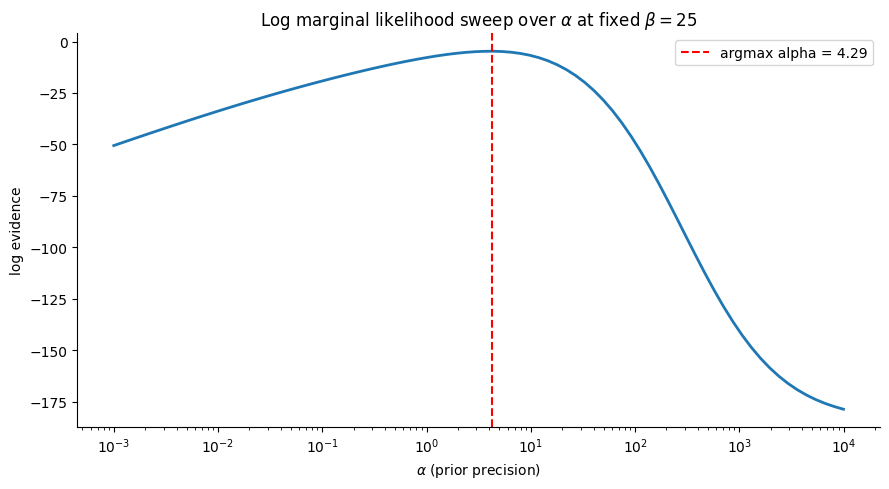

In [2]:
def gaussian_basis(x, centres, width):
    x = np.atleast_2d(x).reshape(-1, 1)
    centres = np.asarray(centres).reshape(1, -1)
    phi = np.exp(-0.5 * (x - centres)**2 / width**2)
    return np.hstack([np.ones_like(x), phi])

def log_evidence(Phi, y, alpha, beta):
    N, M = Phi.shape
    S_inv = alpha * np.eye(M) + beta * Phi.T @ Phi
    L = np.linalg.cholesky(S_inv)
    m = beta * np.linalg.solve(S_inv, Phi.T @ y)
    E = 0.5 * beta * np.sum((y - Phi @ m)**2) + 0.5 * alpha * np.sum(m**2)
    log_det_S_inv = 2 * np.sum(np.log(np.diag(L)))
    return 0.5 * M * np.log(alpha) + 0.5 * N * np.log(beta) - E - 0.5 * log_det_S_inv - 0.5 * N * np.log(2 * np.pi)


# Generate data
def true_f(x):
    return np.sin(2 * np.pi * x) + 0.3 * np.cos(6 * np.pi * x)
rng = np.random.default_rng(0)
N = 30
x_train = rng.uniform(0, 1, size=N)
y_train = true_f(x_train) + rng.normal(0, 0.2, size=N)

centres = np.linspace(0, 1, 15)
width = 0.08
Phi = gaussian_basis(x_train, centres, width)

# Sweep alpha at fixed beta, plot log evidence
alphas = np.logspace(-3, 4, 80)
beta_fixed = 25
le = np.array([log_evidence(Phi, y_train, a, beta_fixed) for a in alphas])

fig, ax = plt.subplots()
ax.semilogx(alphas, le, lw=2)
ax.axvline(alphas[np.argmax(le)], color="red", ls="--", label=f"argmax alpha = {alphas[np.argmax(le)]:.2f}")
ax.set_xlabel(r"$\alpha$ (prior precision)"); ax.set_ylabel("log evidence")
ax.set_title(r"Log marginal likelihood sweep over $\alpha$ at fixed $\beta=25$")
ax.legend(); plt.tight_layout(); plt.show()


## 2. The evidence-approximation update

We do not have to sweep — we can iteratively maximise the evidence by setting its derivatives in $\alpha$, $\beta$ to zero. The result is a self-consistent pair of fixed-point equations involving the **effective number of parameters**:

$$
\gamma \;=\; \sum_{j=1}^{M} \frac{\lambda_j}{\alpha + \lambda_j},
$$

where $\lambda_j$ are the eigenvalues of $\beta \Phi^\top \Phi$. Then

$$
\alpha_{\text{new}} = \frac{\gamma}{m_N^\top m_N}, \qquad \beta_{\text{new}}^{-1} = \frac{\|\mathbf{y} - \Phi m_N\|^2}{N - \gamma}.
$$

We iterate until convergence. Interpretation: $\gamma$ counts the basis functions the data has constrained ("how many directions in weight space are actually informed by the data"). $\alpha$ shrinks toward the inverse mean-squared weight; $\beta$ shrinks toward the inverse of the residual variance, corrected for degrees of freedom by $\gamma$.


iter 0: alpha=1.0000  beta=1.0000  gamma=6.61  log p(y)=-36.6400

Converged: alpha=3.9923, beta=44.9956
Implied noise std: 0.1491    truth: 0.2


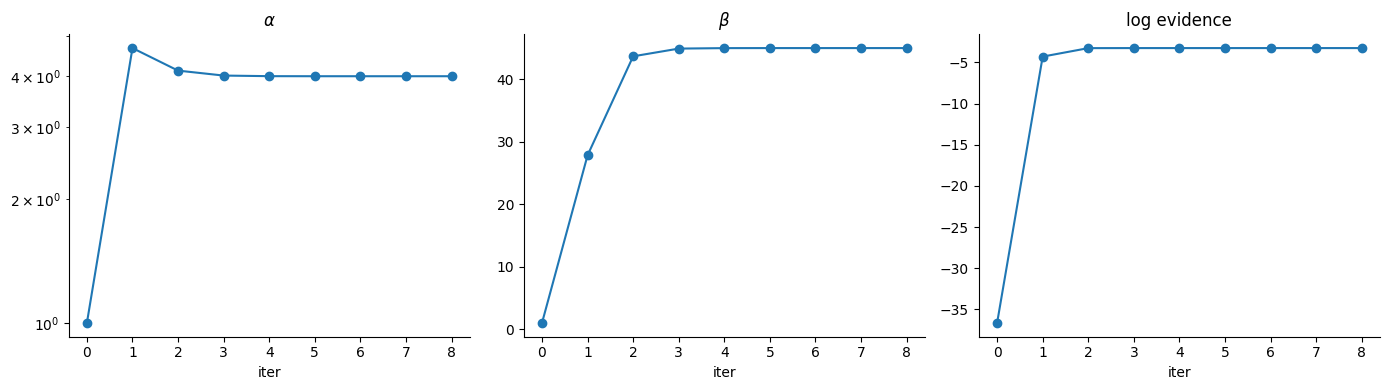

In [3]:
def fit_evidence(Phi, y, max_iter=200, tol=1e-6, alpha0=1.0, beta0=1.0, verbose=False):
    N, M = Phi.shape
    alpha, beta = alpha0, beta0
    eigvals_PhiTPhi = np.linalg.eigvalsh(Phi.T @ Phi)

    history = []
    for it in range(max_iter):
        S_inv = alpha * np.eye(M) + beta * Phi.T @ Phi
        m = beta * np.linalg.solve(S_inv, Phi.T @ y)
        lambdas = beta * eigvals_PhiTPhi
        gamma = np.sum(lambdas / (alpha + lambdas))

        alpha_new = gamma / (m @ m + 1e-12)
        res = y - Phi @ m
        beta_new = (N - gamma) / (res @ res + 1e-12)

        history.append((alpha, beta, gamma, log_evidence(Phi, y, alpha, beta)))
        if verbose and it % 10 == 0:
            print(f"iter {it}: alpha={alpha:.4f}  beta={beta:.4f}  gamma={gamma:.2f}  log p(y)={history[-1][3]:.4f}")
        if abs(alpha_new - alpha) < tol and abs(beta_new - beta) < tol:
            break
        alpha, beta = alpha_new, beta_new

    return alpha, beta, m, S_inv, history


alpha_hat, beta_hat, m_hat, S_inv_hat, hist = fit_evidence(Phi, y_train, verbose=True)
print(f"\nConverged: alpha={alpha_hat:.4f}, beta={beta_hat:.4f}")
print(f"Implied noise std: {1/np.sqrt(beta_hat):.4f}    truth: 0.2")

alphas_h = [h[0] for h in hist]
betas_h = [h[1] for h in hist]
gammas_h = [h[2] for h in hist]
le_h = [h[3] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(alphas_h, "o-"); axes[0].set_yscale("log"); axes[0].set_title(r"$\alpha$"); axes[0].set_xlabel("iter")
axes[1].plot(betas_h, "o-"); axes[1].set_title(r"$\beta$"); axes[1].set_xlabel("iter")
axes[2].plot(le_h, "o-"); axes[2].set_title("log evidence"); axes[2].set_xlabel("iter")
plt.tight_layout(); plt.show()


## 3. Automatic Relevance Determination

ARD replaces the scalar precision $\alpha$ with a *per-feature* precision $\alpha_j$ for each basis function:

$$
p(w) = \prod_{j=1}^{M} \mathcal{N}(w_j \mid 0,\ \alpha_j^{-1}).
$$

After type-II ML, irrelevant basis functions get $\alpha_j \to \infty$, driving $w_j$ to zero. This is a Bayesian **sparsity** mechanism — closely related to the **relevance vector machine**.

The update equations are (Tipping, 2001):

$$
\alpha_j^{\text{new}} = \frac{\gamma_j}{m_{N,j}^2}, \qquad \gamma_j = 1 - \alpha_j (S_N)_{jj}, \qquad \beta^{\text{new}\,-1} = \frac{\|y - \Phi m_N\|^2}{N - \sum_j \gamma_j}.
$$

We demonstrate on a setup with many basis functions where only a few are needed.


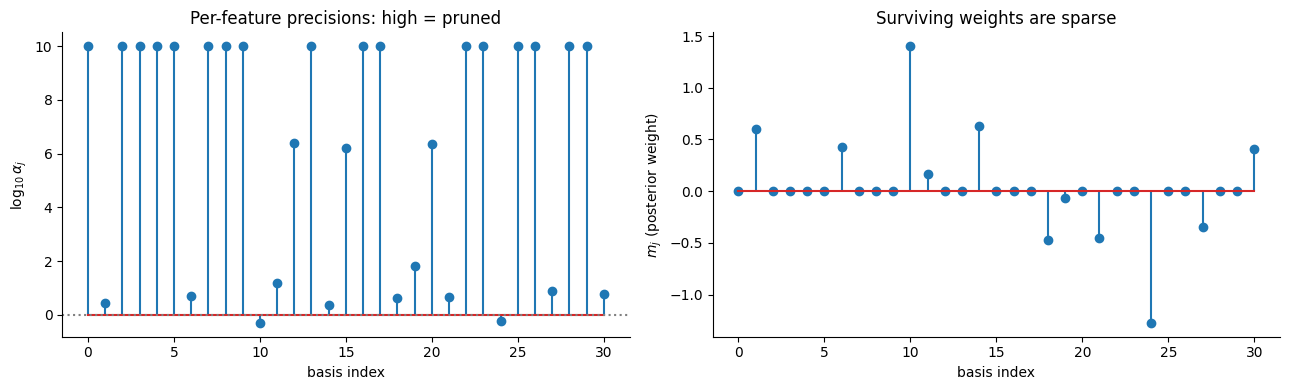

Number of effectively active basis fns (|m_j| > 0.05): 11 / 31


In [4]:
def fit_ard(Phi, y, max_iter=200, tol=1e-5, alpha0=1.0, beta0=1.0):
    N, M = Phi.shape
    alpha = np.full(M, alpha0)
    beta = beta0

    for it in range(max_iter):
        S_inv = np.diag(alpha) + beta * Phi.T @ Phi
        S = np.linalg.inv(S_inv)
        m = beta * S @ Phi.T @ y

        gamma_j = 1.0 - alpha * np.diag(S)
        alpha_new = np.where(m**2 > 1e-12, gamma_j / (m**2 + 1e-12), 1e10)
        # cap alpha so updates stay numerical
        alpha_new = np.clip(alpha_new, 1e-6, 1e10)
        res = y - Phi @ m
        beta_new = (N - gamma_j.sum()) / (res @ res + 1e-12)

        if np.max(np.abs(np.log(alpha_new + 1e-12) - np.log(alpha + 1e-12))) < tol:
            break
        alpha, beta = alpha_new, beta_new

    return alpha, beta, m, S


# Many basis functions, only a few needed
centres_many = np.linspace(0, 1, 30)
Phi_many = gaussian_basis(x_train, centres_many, 0.05)
alpha_ard, beta_ard, m_ard, S_ard = fit_ard(Phi_many, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(np.arange(len(alpha_ard)), np.log10(alpha_ard))
axes[0].set_xlabel("basis index"); axes[0].set_ylabel(r"$\log_{10} \alpha_j$")
axes[0].set_title("Per-feature precisions: high = pruned")
axes[0].axhline(np.log10(1.0), color="grey", ls=":")

axes[1].stem(np.arange(len(m_ard)), m_ard)
axes[1].set_xlabel("basis index"); axes[1].set_ylabel(r"$m_j$ (posterior weight)")
axes[1].set_title("Surviving weights are sparse")
plt.tight_layout(); plt.show()

print(f"Number of effectively active basis fns (|m_j| > 0.05): {(np.abs(m_ard) > 0.05).sum()} / {len(m_ard)}")


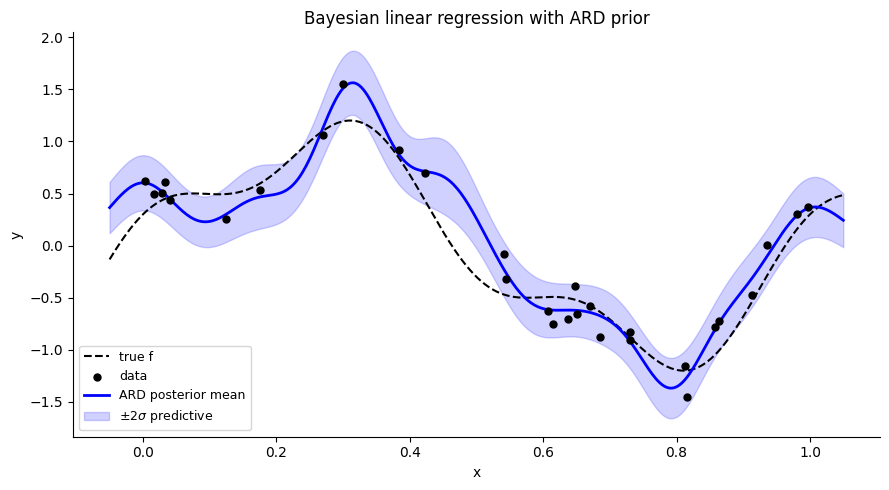

In [5]:
# Visualise ARD fit
x_test = np.linspace(-0.05, 1.05, 400)
Phi_test_many = gaussian_basis(x_test, centres_many, 0.05)
mean_ard = Phi_test_many @ m_ard
var_ard = np.einsum("ij,jk,ik->i", Phi_test_many, S_ard, Phi_test_many) + 1.0 / beta_ard
std_ard = np.sqrt(var_ard)

fig, ax = plt.subplots()
ax.plot(x_test, true_f(x_test), "k--", lw=1.5, label="true f")
ax.scatter(x_train, y_train, c="black", s=25, zorder=3, label="data")
ax.plot(x_test, mean_ard, "b-", lw=2, label="ARD posterior mean")
ax.fill_between(x_test, mean_ard - 2*std_ard, mean_ard + 2*std_ard, alpha=0.18, color="blue",
                label=r"$\pm 2\sigma$ predictive")
ax.set_title("Bayesian linear regression with ARD prior")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()


## 4. Take-aways

- The marginal likelihood is a closed-form scalar that scores how well a model **as a whole** explains the data. Cross-validation is one way to do model selection; marginal likelihood is another.
- Type-II ML (empirical Bayes) gives a principled way to set hyperparameters without a held-out set.
- ARD is a sparsity mechanism that emerges purely from Bayesian model selection: features that do not help fit the data get pruned.

## 5. Exercises

**Exercise 2.5.** Derive the closed form of $\log p(\mathbf{y} \mid \alpha, \beta)$ by completing the square in $w$ and using the Gaussian integral $\int \exp(-\tfrac{1}{2}(w - m)^\top A (w - m))\, dw = (2\pi)^{M/2} |A|^{-1/2}$.

**Exercise 2.6 (Effective parameters).** Prove that $\gamma \in [0, M]$. When is $\gamma \approx M$? When is $\gamma \ll M$?

**Exercise 2.7 (Polynomial degree).** Use the evidence approximation to choose the *degree* of a polynomial basis for a synthetic problem. Compare against cross-validation. Comment on the difference.

**Exercise 2.8 (ARD vs Lasso).** Both ARD and Lasso induce sparsity. Compare their behaviour on a synthetic problem with correlated features. Which one is more aggressive about pruning, and why?
